# Final Project - Client Feedback Sentiment Analyzer

Objective:
Analyze client feedback and predict sentiment using Machine Learning models.

In [ ]:
import pandas as pd

True


## Dataset Loading

In [5]:
from google.colab import files

uploaded = files.upload()

Saving coretech_feedback.csv to coretech_feedback.csv


In [6]:
import pandas as pd

df = pd.read_csv("coretech_feedback.csv")

df.head()

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1,Ali Corp,Web Development,Excellent service and support,5,Positive
1,2,Tech Solutions,Mobile App,Average experience,3,Neutral
2,3,ABC Ltd,Data Analytics,Poor communication,2,Negative
3,4,Alpha Tech,Web Development,Very satisfied with results,5,Positive
4,5,Beta Systems,Cloud Service,Service was okay,3,Neutral


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Feedback_ID    30 non-null     int64 
 1   Client_Name    30 non-null     object
 2   Service        30 non-null     object
 3   Feedback_Text  30 non-null     object
 4   Rating         30 non-null     int64 
 5   Sentiment      30 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.5+ KB
None


In [8]:
print(df.isnull().sum())

Feedback_ID      0
Client_Name      0
Service          0
Feedback_Text    0
Rating           0
Sentiment        0
dtype: int64


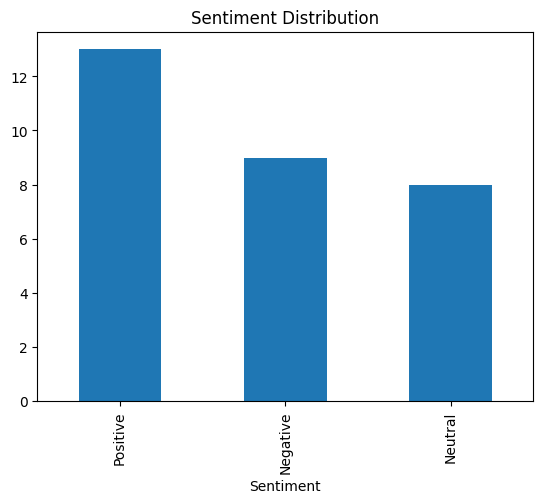

In [10]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.show()

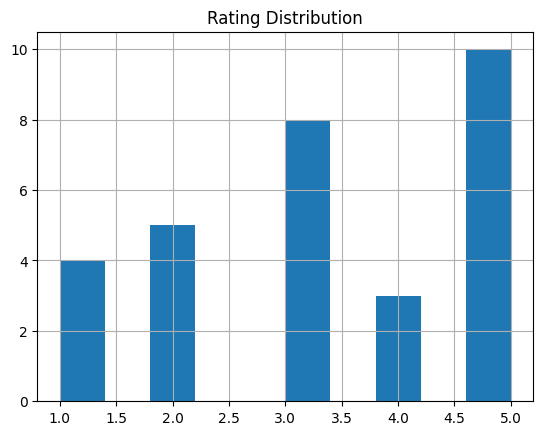

In [11]:
df["Rating"].hist()

plt.title("Rating Distribution")

plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Feedback_Text"])

y = df["Sentiment"]

print(X.shape)

(30, 47)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train/Test Split Completed")

Train/Test Split Completed


In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.6666666666666666


In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8333333333333334


In [17]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy]
})

print(comparison)

                 Model  Accuracy
0          Naive Bayes  0.666667
1  Logistic Regression  0.833333


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67         2
     Neutral       1.00      1.00      1.00         2
    Positive       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



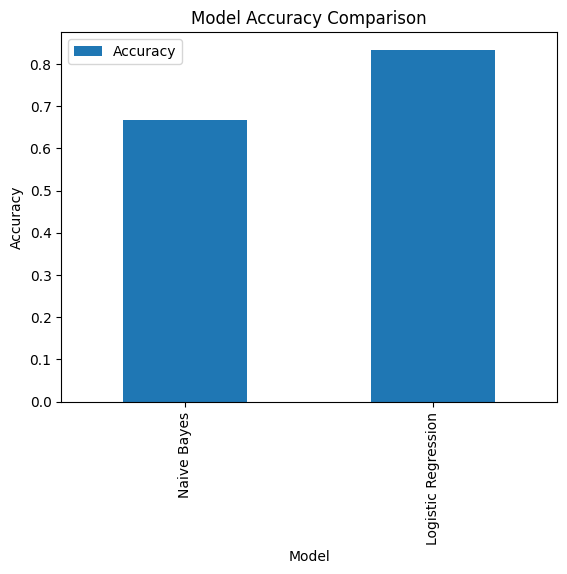

In [20]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

## Business Insights

• Most clients provided positive feedback.

• Negative feedback highlights areas that require improvement.

• Positive feedback indicates strong customer satisfaction.

• Sentiment analysis helps organizations identify customer needs and improve service quality.

• Businesses can use sentiment prediction to improve customer retention and decision-making.

## Best Model Selection

Two machine learning models were trained and compared:

1. Naive Bayes
2. Logistic Regression

Logistic Regression achieved higher accuracy than Naive Bayes.

Therefore, Logistic Regression was selected as the final model for sentiment prediction.

## Conclusion

A Client Feedback Sentiment Analyzer was successfully developed.

The project included:
- Dataset Creation
- Data Preprocessing
- Exploratory Data Analysis
- TF-IDF Vectorization
- Model Training
- Model Comparison
- Performance Evaluation
- Business Insights

Among all models, Logistic Regression achieved the best performance and was selected as the final model.